In [199]:
# Importacion de librerias principales para analisis y visualizacion
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from wordcloud import WordCloud
import re
from collections import Counter
import pycountry

pd.set_option('display.float_format', '{:.2f}'.format) #cortamos la muestra de decimales a 2

In [89]:
df = pd.read_csv("set_datos_arreglo.csv", engine="python", sep=None )   # Carga del dataset ya depurado previamente
                                          # engine="python" permite manejar separadores irregulares y sep=None deja que pandas detecte el delimitador.
df.head()                    # Vista de las primeras filas para verificar estructura y contenido

,﻿Column1.1,Column1.2,Column1.3,Column1.4,Column1.5,Column1.6,Column1.7,Column1.8,Column1.9,Column1.10,Column1.11,Column1.12,Column1.13,Column1.14,Column1.15,Column1.16
0,NaN,country,description,designation,points,price,province,region_1,region_2,taster_name,taster_twitter_handle,title,variety,winery;;;;,NaN,NaN
1,0.00,Italy,"Aromas include tropical fruit, broom, brimston...",Vulkà Bianco,87,NaN,Sicily & Sardinia,Etna,NaN,Kerin O’Keefe,@kerinokeefe,Nicosia 2013 Vulkà Bianco (Etna),White Blend,Nicosia;;;;,NaN,NaN
2,1.00,Portugal,"This is ripe and fruity, a wine that is smooth...",Avidagos,87,15.0,Douro,NaN,NaN,Roger Voss,@vossroger,Quinta dos Avidagos 2011 Avidagos Red (Douro),Portuguese Red,Quinta dos Avidagos;;;;,NaN,NaN
3,2.00,US,"Tart and snappy, the flavors of lime flesh and...",NaN,87,14.0,Oregon,Willamette Valley,Willamette Valley,Paul Gregutt,@paulgwine,Rainstorm 2013 Pinot Gris (Willamette Valley),Pinot Gris,Rainstorm;;;;,NaN,NaN
4,3.00,US,"Pineapple rind, lemon pith and orange blossom ...",Reserve Late Harvest,87,13.0,Michigan,Lake Michigan Shore,NaN,Alexander Peartree,NaN,St. Julian 2013 Reserve Late Harvest Riesling ...,Riesling,St. Julian;;;;,NaN,NaN


In [90]:
df = pd.read_csv("set_datos_arreglo.csv", sep=";", header=None, low_memory=False) # Se lee el set de datos sin la primera fila
                                                                                  # Porque esta no contiene nombres como column1 y no sera necesaria.
# Se toma la primera fila como encabezado real (con los nombres de las columnas creadas en la tabla de MySQL)
header = df.iloc[1].tolist()

# Me quedo con todas las filas menos las primeras 2 filas (0 y 1)
df = df[2:].reset_index(drop=True)

# Asigno los nombres de columnas correctos
df.columns = header


In [91]:
df = df.iloc[:, :-2]    # Se elimina las dos ultimas columnas que contienen en su gran mayoria datos nulos NaN

In [92]:
cols = df.columns.tolist() 
cols[0] = "num_resena"   
df.columns = cols          # Se obtiene la lista de nombres de columnas para poder modificarlas.

df = df.rename(columns={"winery;;;;": "winery"}) #Renombro columna winery tenia ; innecesarios

df["winery"] = df["winery"].str.replace(";", "", regex=False)  # Se limpian los ';;;;' del final que contienen las filas en la columna winery

In [93]:
# Chequeo de la estructura del dataframe luego de la limpieza
df.shape    
df.columns
df.head()

,num_resena,country,description,designation,points,price,province,region_1,region_2,taster_name,taster_twitter_handle,title,variety,winery
0,0,Italy,"Aromas include tropical fruit, broom, brimston...",Vulkà Bianco,87,NaN,Sicily & Sardinia,Etna,NaN,Kerin O’Keefe,@kerinokeefe,Nicosia 2013 Vulkà Bianco (Etna),White Blend,Nicosia
1,1,Portugal,"This is ripe and fruity, a wine that is smooth...",Avidagos,87,15.0,Douro,NaN,NaN,Roger Voss,@vossroger,Quinta dos Avidagos 2011 Avidagos Red (Douro),Portuguese Red,Quinta dos Avidagos
2,2,US,"Tart and snappy, the flavors of lime flesh and...",NaN,87,14.0,Oregon,Willamette Valley,Willamette Valley,Paul Gregutt,@paulgwine,Rainstorm 2013 Pinot Gris (Willamette Valley),Pinot Gris,Rainstorm
3,3,US,"Pineapple rind, lemon pith and orange blossom ...",Reserve Late Harvest,87,13.0,Michigan,Lake Michigan Shore,NaN,Alexander Peartree,NaN,St. Julian 2013 Reserve Late Harvest Riesling ...,Riesling,St. Julian
4,4,US,"Much like the regular bottling from 2012, this...",Vintner's Reserve Wild Child Block,87,65.0,Oregon,Willamette Valley,Willamette Valley,Paul Gregutt,@paulgwine,Sweet Cheeks 2012 Vintner's Reserve Wild Child...,Pinot Noir,Sweet Cheeks


In [238]:
# Conversion de la columna points y price a tipo numerico.
# errors='coerce' convierte cualquier valor no numerico en NaN, util para limpiar datos inconsistentes.
# Permitiendo realizar analisis estadisticos y graficos sin errores.
df['points'] = pd.to_numeric(df['points'], errors= 'coerce')
df['price'] = pd.to_numeric(df['price'], errors='coerce')  


In [95]:
 #cheuqeo de tipos de datos
df.dtypes        

num_resena                   str
country                      str
description                  str
designation                  str
points                   float64
price                    float64
province                     str
region_1                     str
region_2                     str
taster_name                  str
taster_twitter_handle        str
title                        str
variety                      str
winery                       str
dtype: object

<function matplotlib.pyplot.show(close=None, block=None)>

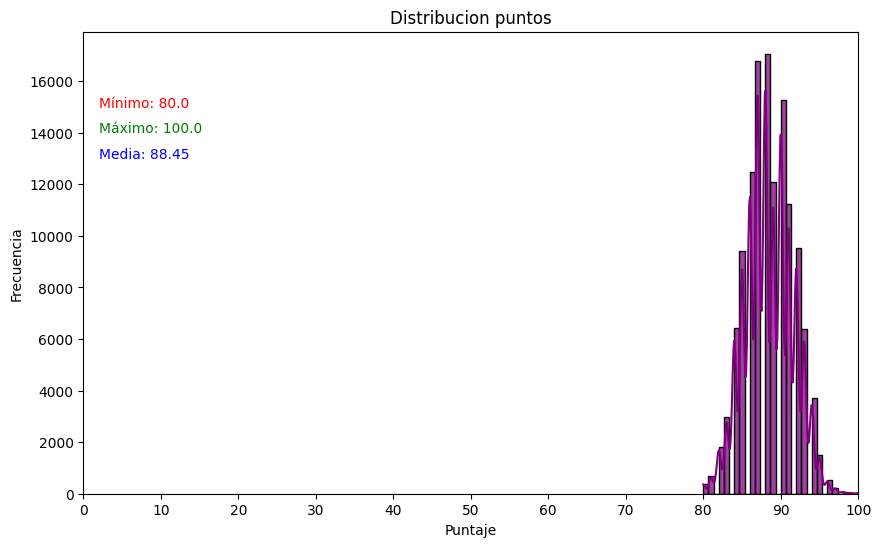

In [96]:
# Se reemplazan valores mayores a 100 en points por None (NaN) para corregir errores de carga
df.loc[df['points'] > 100, 'points'] = None

 #Calculo de estadisticas basicas para el grafico
min_val = df['points'].min()            
max_val = df['points'].max()
mean_val = df['points'].mean

#histograma distribucion de puntos
plt.figure(figsize=(10,6))                 
sns.histplot(df['points'], kde=True, bins=30, color='purple', alpha=0.75)
# Titulos y etiquetas
plt.title('Distribucion puntos')         
plt.xlabel('Puntaje')                     #le damos nombre a los ejes x e y un titulo, tamaño y color
plt.ylabel('Frecuencia')
                                          
plt.xlim(0,100)                           #ajustamos los ejes x e y, rango y division.
plt.xticks(range(0,101,10))
plt.yticks(range(0, 16001, 2000))

plt.text(2, 15000, f"Mínimo: {min_val}", color='red')       #se muestra los valores
plt.text(2, 14000, f"Máximo: {max_val}", color='green')    #min, max y media en el grafico
plt.text(2, 13000, f"Media: {mean_val:.2f}", color='blue')

plt.show

<function matplotlib.pyplot.show(close=None, block=None)>

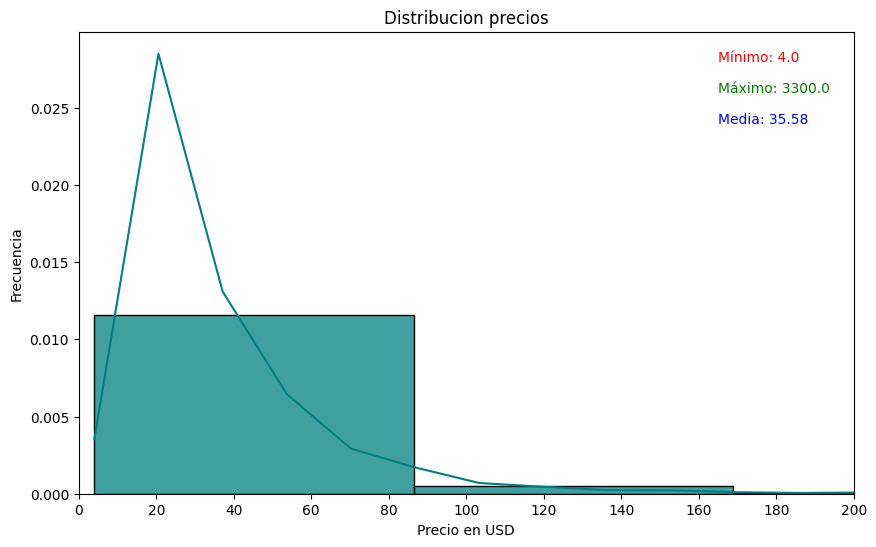

In [97]:
 #Estadisticas basicas de la variable price
min_price = df['price'].min()             
max_price = df['price'].max()
mean_price = df['price'].mean()

#histograma distribucion de precios
plt.figure(figsize=(10,6))                 
sns.histplot(df['price'], kde=True, bins=40, color='teal', alpha=0.75, stat = 'density')
plt.title('Distribucion precios')          # Se usa stat='density' para normalizar el area del histograma y facilitar la lectura
plt.xlabel('Precio en USD')                 #le damos nombre a los ejes x e y un titulo, tamaño y color
plt.ylabel('Frecuencia')

plt.xlim(0,200)     #ponemos este  rango ya que el valor maximo es muy alto y 'deforma' el grafico
plt.xticks(range(0,201,20))
                                          
plt.text(165, 0.028, f"Mínimo: {min_price}", color='red')       #se muestra los valores
plt.text(165, 0.026, f"Máximo: {max_price}", color='green')    #min, max y media en el grafico
plt.text(165, 0.024, f"Media: {mean_price:.2f}", color='blue')

plt.show

In [98]:
#Info variable country
cant_datos_country=df['country'].count()  # Cantidad de datos NO nulos
cant_paises=df['country'].nunique()       # Cantidad de paises distintos
freq_paises=df['country'].value_counts()  # Frecuencia de aparicion de cada pais (ordenado de mayor a menor)
nulls_paises=df['country'].isna().sum()   # Cantidad de valores nulos

# Impresion de resultados
print('Datos validos:', cant_datos_country)
print('Datos nulos:', nulls_paises)
print('Cantidad de paises distintos:', cant_paises)
print('Frecuencia de paises:', freq_paises)

Datos validos: 129908
Datos nulos: 63
Cantidad de paises distintos: 43
Frecuencia de paises: country
US                        54504
France                    22093
Italy                     19540
Spain                      6645
Portugal                   5691
Chile                      4472
Argentina                  3800
Austria                    3345
Australia                  2329
Germany                    2165
New Zealand                1419
South Africa               1401
Israel                      505
Greece                      466
Canada                      257
Hungary                     146
Bulgaria                    141
Romania                     120
Uruguay                     109
Turkey                       90
Slovenia                     87
Georgia                      86
England                      74
Croatia                      73
Mexico                       70
Moldova                      59
Brazil                       52
Lebanon                      35
Mor

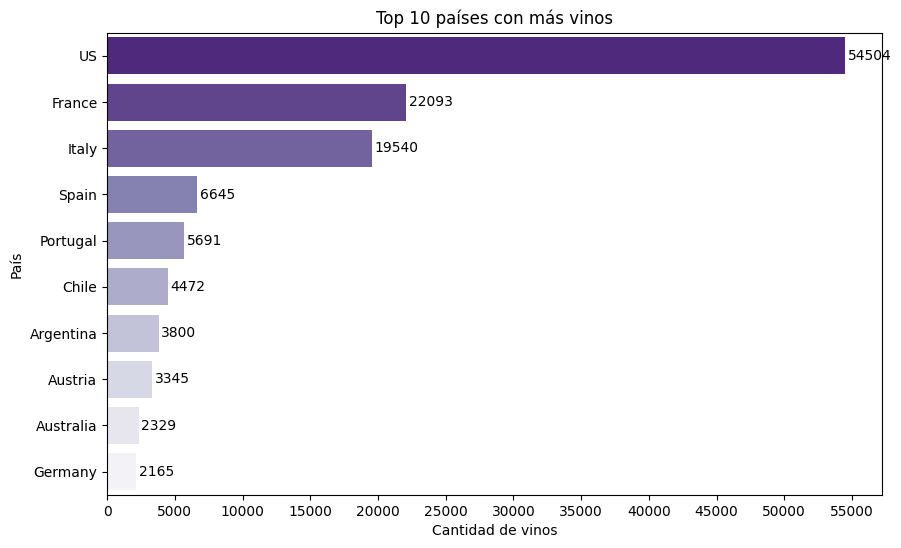

In [99]:
#Top 10 paises con mas cantidad de vinos
plt.figure(figsize=(10,6))
top_countries = df['country'].value_counts().head(10) # Se obtiene la frecuencia de paises y se seleccionan los 10 con mas registros

# Grafico de barras 
gb_country=sns.barplot(
    x=top_countries.values,
    y=top_countries.index,
    hue=top_countries.index,
    palette='Purples_r',
    legend=False 
)

# Agregar etiquetas al final de cada barra 
for i, value in enumerate(top_countries.values):
    gb_country.text(
        value + 200,          # desplazamiento a la derecha
        i,                    # posicion vertical
        str(value),           # texto = cantidad
        va='center'  )

#  Configurar intervalos del eje X 
plt.xticks(range(0, max(top_countries.values) + 5000, 5000))

# Titulos y etiquetas
plt.title('Top 10 países con más vinos')
plt.xlabel('Cantidad de vinos')
plt.ylabel('País')
plt.show()

In [100]:
#Info variable variety
cant_datos_variety=df['variety'].count() # Cantidad de datos NO nulos
cant_variedades=df['variety'].nunique() # Cantidad total de variedades distintas
freq_variedades=df['variety'].value_counts() # Frecuencia de cada variedad (ordenada de mayor a menor)
nulls_variedades=df['variety'].isna().sum() # Cantidad de valores nulos

# Impresion de resultados
print('Datos validos:', cant_datos_variety)
print('Datos nulos:', nulls_variedades)
print('Cantidad de variedades distintas:', cant_variedades)
print('Frecuencia de variedades:', freq_variedades)

Datos validos: 129815
Datos nulos: 156
Cantidad de variedades distintas: 1236
Frecuencia de variedades: variety
Pinot Noir                                                                     13114
Chardonnay                                                                     11654
Cabernet Sauvignon                                                              9327
Red Blend                                                                       8842
Bordeaux-style Red Blend                                                        6882
                                                                               ...  
Plaisance Ranch 2014 Malbec (Applegate Valley)                                     1
Russian River Vineyards 2009 Estate Grown Pinot Noir (Russian River Valley)        1
MontGras 2007 Reserva Cabernet Sauvignon (Colchagua Valley)                        1
Bobal-Cabernet Sauvignon                                                           1
Chateau Ste. Michelle 2007 Merlot (Col

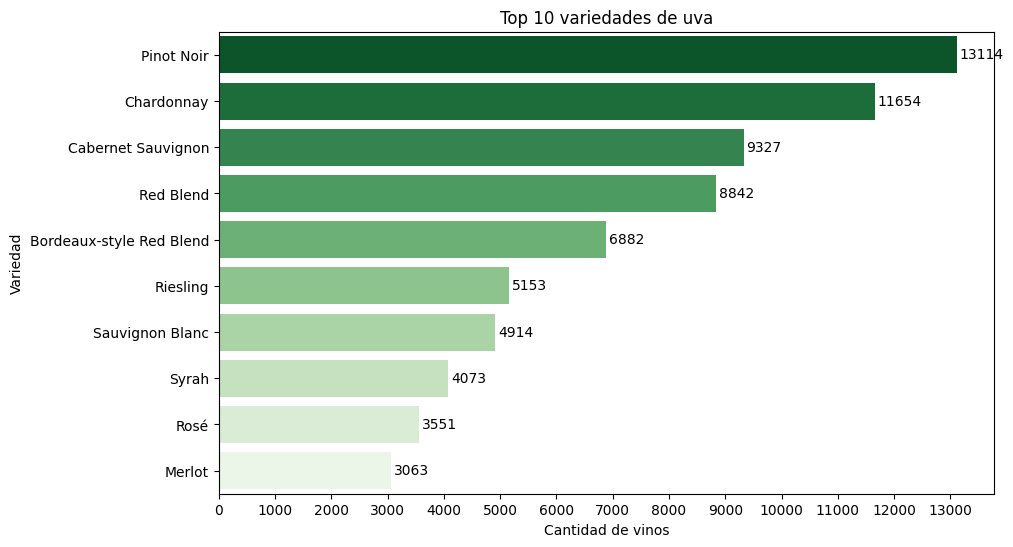

In [124]:
#Top 10 variedades con mas vinos 
plt.figure(figsize=(10,6))
top_varieties = df['variety'].value_counts().head(10) # Se obtiene la frecuencia de cada variedad y se seleccionan las 10 mas comunes

# Grafico de barras
gb_variety=sns.barplot(
    x=top_varieties.values,
    y=top_varieties.index,
    hue=top_varieties.index,
    palette='Greens_r'
)

# Etiquetas al final de cada barra 
for i, value in enumerate(top_varieties.values):
    gb_variety.text(
        value + 50,          # desplazamiento a la derecha
        i,                    # posición vertical
        str(value),           # texto = cantidad
        va='center'  
    )

#  Configurar intervalos del eje X 
plt.xticks(range(0, max(top_varieties.values) + 500, 1000))

# Titulos y etiquetas
plt.title('Top 10 variedades de uva')
plt.xlabel('Cantidad de vinos')
plt.ylabel('Variedad')
plt.show()

In [102]:
#Info variable winery
cant_datos_winery=df['winery'].count()   # Cantidad de datos NO nulos
cant_winery=df['winery'].nunique()       # Cantidad total de bodegas distintas
freq_winery=df['winery'].value_counts()  # Frecuencia de aparicion de cada bodega (ordenada de mayor a menor)
nulls_winery=df['winery'].isna().sum()   # Cantidad de valores nulos 

# Impresion de resultados
print('Datos validos:', cant_datos_winery)
print('Datos nulos:',nulls_winery)
print('Cantidad de bodegas:', cant_winery)
print('Frecuencia bodegas:', freq_winery)

Datos validos: 129868
Datos nulos: 103
Cantidad de bodegas: 17134
Frecuencia bodegas: winery
Wines & Winemakers                                         222
Testarossa                                                 218
DFJ Vinhos                                                 214
Williams Selyem                                            207
Louis Latour                                               199
                                                          ... 
Flagstone                                                    1
Mas de Pampelonne                                            1
Bodegas Eidosela                                             1
Penedo Borges                                                1
Ricardo Santos 2006 La Madras Vineyard Malbec (Mendoza)      1
Name: count, Length: 17134, dtype: int64


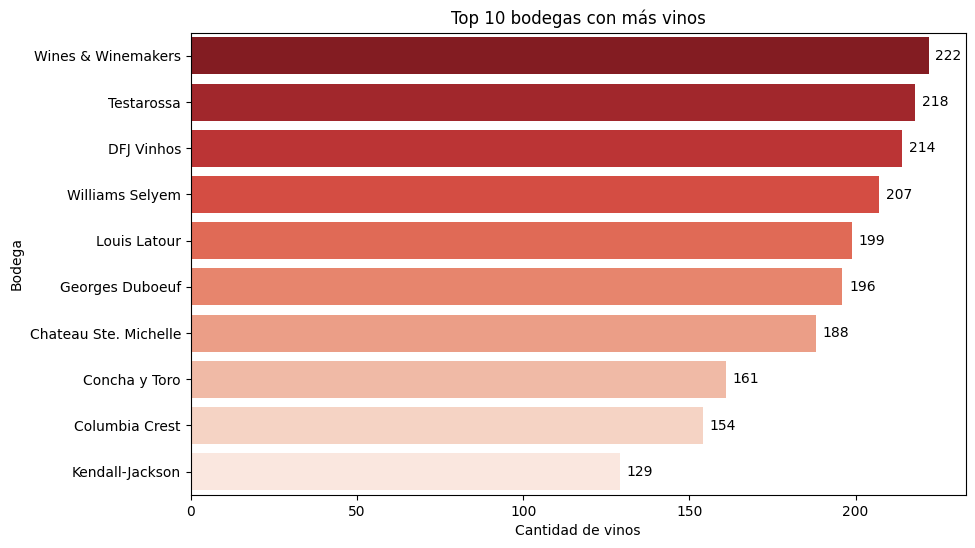

In [103]:
#Top 10 bodegas con mas vinos
plt.figure(figsize=(10,6))
top_winery = df['winery'].value_counts().head(10) # Se obtiene la frecuencia de cada bodega y se seleccionan las 10 mas comunes

# Grafico de barras
gb_winery = sns.barplot(
    x=top_winery.values,
    y=top_winery.index,
    hue=top_winery.index,
    palette='Reds_r'
)

# Etiquetas al final de cada barra
for i, value in enumerate(top_winery.values):
    gb_winery.text(
        value + 2,   # desplazamiento a la derecha
        i,
        str(value),
        va='center'
    )

# Titulos y etiquetas
plt.title('Top 10 bodegas con más vinos')
plt.xlabel('Cantidad de vinos')
plt.ylabel('Bodega')
plt.show()

In [104]:
# Promedios por pais
prom_puntos_pais = df.groupby('country')[['points']].mean()
prom_precio_pais = df.groupby('country')[['price']].mean()

# Promedios por bodega
prom_puntos_bodega = df.groupby('winery')[['points']].mean()
prom_precio_bodega = df.groupby('winery')[['price']].mean()

# Promedios por variedad
prom_puntos_variedad = df.groupby('variety')[['points']].mean()
prom_precio_variedad = df.groupby('variety')[['price']].mean()

# Impresion de los resultados
print(prom_puntos_pais.sort_values('points', ascending=False))
print(prom_precio_pais.sort_values('price', ascending=False))
print(prom_puntos_bodega.sort_values('points', ascending=False))
print(prom_precio_bodega.sort_values('price', ascending=False))
print(prom_puntos_variedad.sort_values('points', ascending=False))
print(prom_precio_variedad.sort_values('price', ascending=False))

                        points
country                       
England                  91.58
India                    90.22
Austria                  90.09
Germany                  89.85
Canada                   89.35
Hungary                  89.19
China                    89.00
France                   88.84
Luxembourg               88.67
Australia                88.59
Switzerland              88.57
Morocco                  88.57
Italy                    88.56
US                       88.56
Israel                   88.48
New Zealand              88.30
Portugal                 88.25
Turkey                   88.09
Slovenia                 88.07
South Africa             88.04
Bulgaria                 87.94
Georgia                  87.69
Lebanon                  87.69
Serbia                   87.50
Armenia                  87.50
Spain                    87.28
Greece                   87.28
Czech Republic           87.25
Croatia                  87.22
Moldova                  87.20
Cyprus  

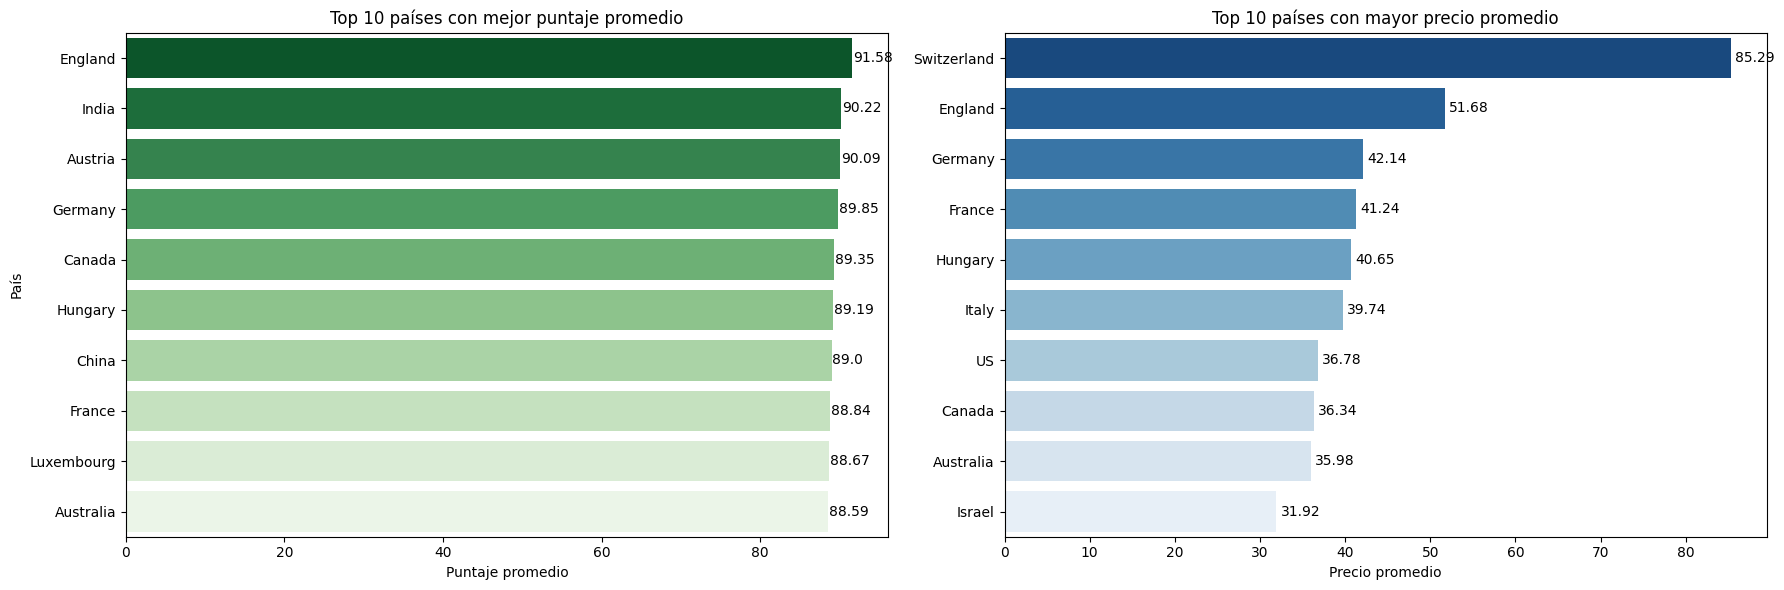

In [105]:
# Top 10 paises por puntos y precio ordenamos las variables de promedio de mayor a menor para usarlas para hacer los graficos
top10_puntos_pais = prom_puntos_pais.sort_values('points', ascending=False).head(10)
top10_precio_pais = prom_precio_pais = df.groupby('country')[['price']].mean().sort_values('price', ascending=False).head(10)

# Crear figura con 2 graficos lado a lado
fig, axes = plt.subplots(1, 2, figsize=(18,6))

# Grafico Puntaje promedio
sns.barplot(
    x=top10_puntos_pais['points'],
    y=top10_puntos_pais.index,
    hue=top10_puntos_pais.index,
    palette='Greens_r',
    ax=axes[0]
)
axes[0].set_title('Top 10 países con mejor puntaje promedio')
axes[0].set_xlabel('Puntaje promedio')
axes[0].set_ylabel('País')

# Etiquetas numericas al final de cada barra
for i, value in enumerate(top10_puntos_pais['points']):  #bucle for para ubicar etiquetas en los graficos
    axes[0].text(value + 0.1, i, round(value,2), va='center')

#Grafico 2: Precio promedio
sns.barplot(
    x=top10_precio_pais['price'],
    y=top10_precio_pais.index,
    hue=top10_precio_pais.index,
    palette='Blues_r',
    ax=axes[1]
)
axes[1].set_title('Top 10 países con mayor precio promedio')
axes[1].set_xlabel('Precio promedio')
axes[1].set_ylabel('')

# Etiquetas numericas al final de cada barra
for i, value in enumerate(top10_precio_pais['price']): #bucle for para ubicar etiquetas en los graficos
    axes[1].text(value + 0.5, i, round(value,2), va='center')

plt.tight_layout()
plt.show()

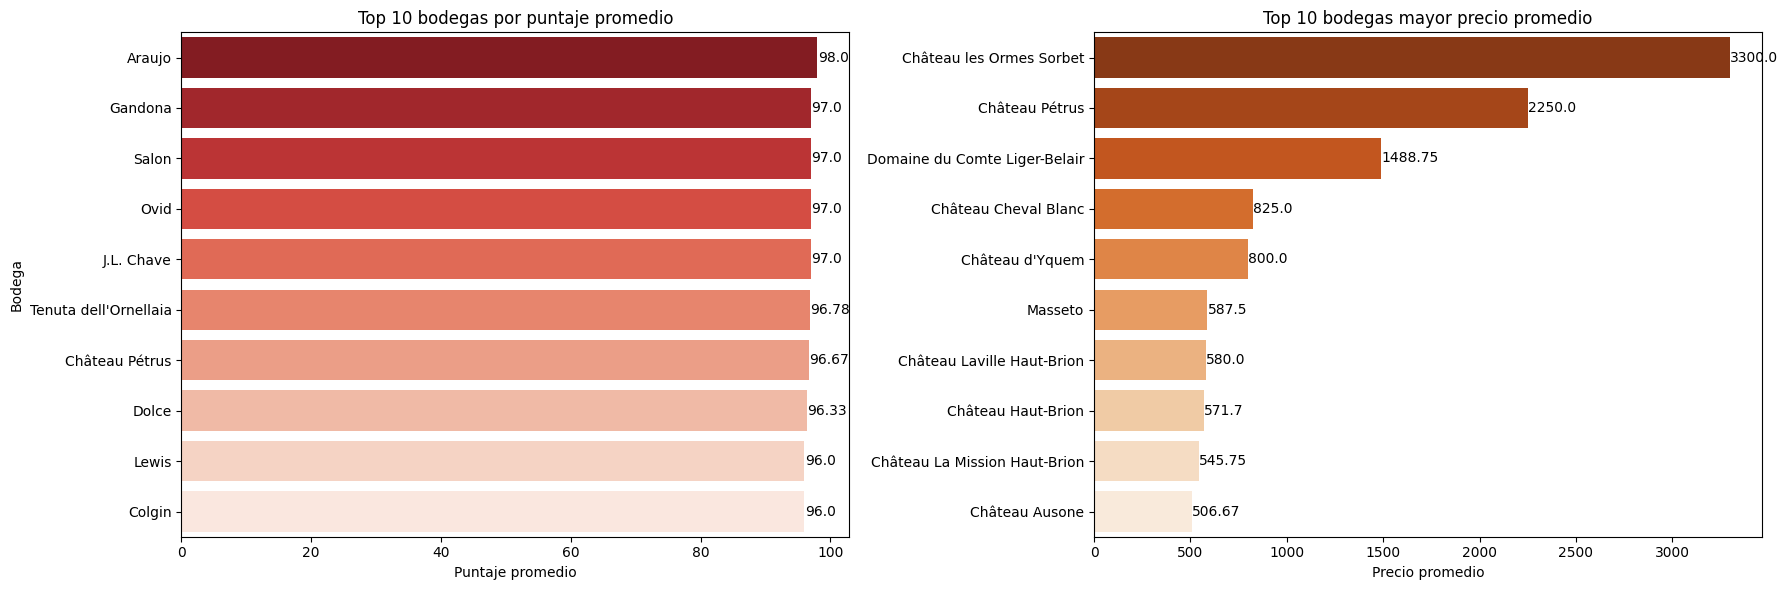

In [106]:
# Top 10 bodegas por puntos y precio ordenamos las variables de promedio de mayor a meno para usarlas para hacer los graficos
top10_puntos_bodega = prom_puntos_bodega.sort_values('points', ascending=False).head(10)
top10_precio_bodega = prom_precio_bodega.sort_values('price', ascending=False).head(10)

#Creacion de figura con dos graficos lado a lado 
fig, axes = plt.subplots(1, 2, figsize=(18,6))

# Grafico puntos
sns.barplot(
    x=top10_puntos_bodega['points'],
    y=top10_puntos_bodega.index,
    hue=top10_puntos_bodega.index,
    palette='Reds_r',
    ax=axes[0]
)
axes[0].set_title('Top 10 bodegas por puntaje promedio')
axes[0].set_xlabel('Puntaje promedio')
axes[0].set_ylabel('Bodega')

# Etiquetas numericas al final de cada barra
for i, value in enumerate(top10_puntos_bodega['points']): #bucle for para ubicar etiquetas en los graficos
    axes[0].text(value + 0.1, i, round(value,2), va='center')

#Grafico precio
sns.barplot(
    x=top10_precio_bodega['price'],
    y=top10_precio_bodega.index,
    hue=top10_precio_bodega.index,
    palette='Oranges_r',
    ax=axes[1]
)
axes[1].set_title('Top 10 bodegas mayor precio promedio')
axes[1].set_xlabel('Precio promedio')
axes[1].set_ylabel('')

# Etiquetas numericas al final de cada barra
for i, value in enumerate(top10_precio_bodega['price']): #bucle for para ubicar etiquetas en los graficos
    axes[1].text(value + 0.5, i, round(value,2), va='center')

plt.tight_layout()
plt.show()


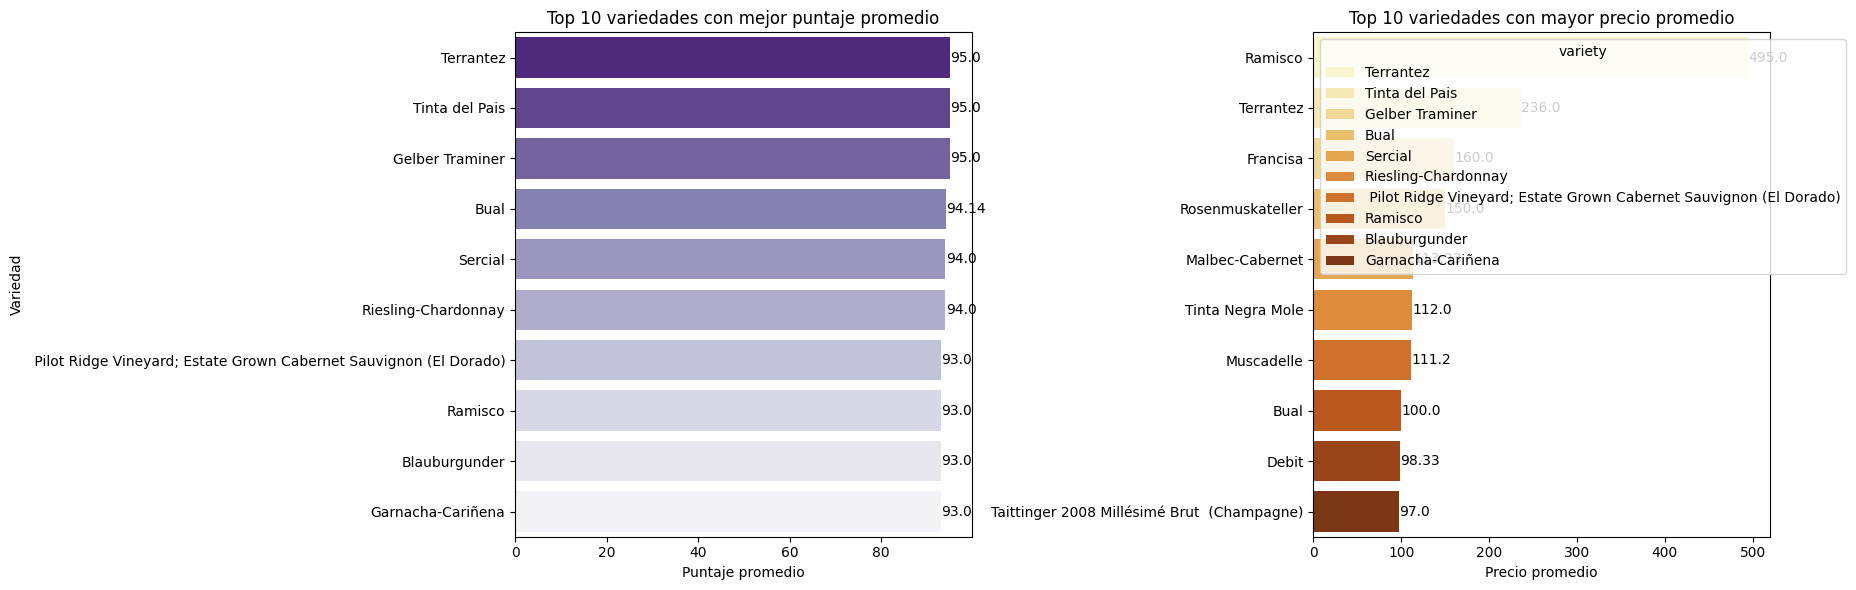

In [107]:
# Top 10 variedades por puntos y precio ordenamos las variables de promedio de mayor a menor para usarlas para hacer los graficos
top10_puntos_variedad = prom_puntos_variedad.sort_values('points', ascending=False).head(10)
top10_precio_variedad = prom_precio_variedad.sort_values('price', ascending=False).head(10)

# Creacion de figura con dos graficos lado a lado
fig, axes = plt.subplots(1, 2, figsize=(18,6))

# Grafico puntaje
sns.barplot(
    x=top10_puntos_variedad['points'],
    y=top10_puntos_variedad.index,
    hue=top10_puntos_variedad.index,
    palette='Purples_r',
    ax=axes[0]
)
axes[0].set_title('Top 10 variedades con mejor puntaje promedio')
axes[0].set_xlabel('Puntaje promedio')
axes[0].set_ylabel('Variedad')

# Etiquetas numericas al final de cada barra
for i, value in enumerate(top10_puntos_variedad['points']): #bucle for para ubicar etiquetas en los graficos
    axes[0].text(value + 0.1, i, round(value,2), va='center')

#Grafico precio
sns.barplot(
    x=top10_precio_variedad['price'],
    y=top10_precio_variedad.index,
    hue=top10_precio_variedad.index,
    palette='YlOrBr',
    ax=axes[1]
)
axes[1].set_title('Top 10 variedades con mayor precio promedio')
axes[1].set_xlabel('Precio promedio')
axes[1].set_ylabel('')

# Etiquetas numericas al final de cada barra
for i, value in enumerate(top10_precio_variedad['price']): #bucle for para ubicar etiquetas en los graficos
    axes[1].text(value + 0.5, i, round(value,2), va='center')

plt.tight_layout()
plt.show()

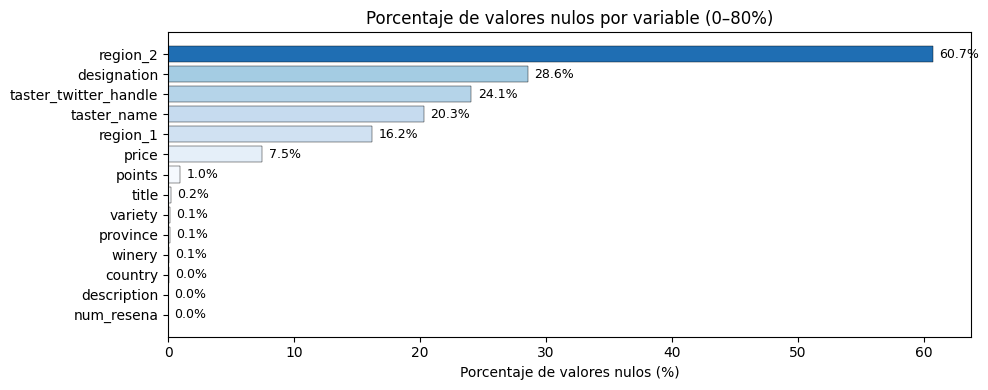

In [108]:
# Calcular porcentaje de nulos por columna
null_percent = (df.isna().sum() / len(df)) * 100
missing_df = pd.DataFrame({              # Se arma un DataFrame con el conteo y porcentaje de nulos
    'null_count': df.isna().sum(),
    'null_percent': null_percent             
}).sort_values('null_percent', ascending=True)

# Selección de columnas a graficar (None = todas).
top_n = None
plot_df = missing_df.tail(top_n) if top_n else missing_df

# Colormap en escala de azules y normalización 0-80
cmap = plt.cm.Blues
norm = mpl.colors.Normalize(vmin=0, vmax=80)
colors = cmap(norm(plot_df['null_percent'].values))

# Grafico 
plt.figure(figsize=(10, max(4, 0.25 * len(plot_df))))
bars = plt.barh(plot_df.index, plot_df['null_percent'], color=colors, edgecolor='k', linewidth=0.3)
plt.xlabel('Porcentaje de valores nulos (%)')
plt.title('Porcentaje de valores nulos por variable (0–80%)')
plt.xlim(0, 80)

# Anotar porcentaje en cada barra
for i, (val, name) in enumerate(zip(plot_df['null_percent'], plot_df.index)):
    plt.text(val + 0.5, i, f"{val:.1f}%", va='center', fontsize=9)

plt.tight_layout()
plt.show()

In [109]:
# Conteo de nulos por columna y tabla resumen
cant_nulls = df.isna().sum()                   #Cantidad de nulos por columna
porcent_nulls = (cant_nulls / len(df)) * 100   #Porcentaje de nulos por columna
nulos_df = pd.DataFrame({                      #DataFrame resumen ordenado de mayor a menor cantidad de nulos
    'cant_nulls': cant_nulls,
    'porcent_nulls': porcent_nulls
}).sort_values('cant_nulls', ascending=False)

# Mostrar las primeras 20 filas del resumen
nulos_df.head(20)

,cant_nulls,porcent_nulls
region_2,78905,60.71
designation,37130,28.57
taster_twitter_handle,31295,24.08
taster_name,26378,20.30
region_1,21080,16.22
price,9740,7.49
points,1256,0.97
title,253,0.19
variety,156,0.12
province,152,0.12


In [110]:
# imputar columnas categóricas con faltantes moderados "Unknown" 
df['designation'] = df['designation'].fillna('Unknown')
df['taster_name'] = df['taster_name'].fillna('Unknown')
df['taster_twitter_handle'] = df['taster_twitter_handle'].fillna('Unknown')
df['region_1'] = df['region_1'].fillna('Unknown')
df['title'] = df['title'].fillna('Unknown')
df['variety'] = df['variety'].fillna('Unknown')
df['province'] = df['province'].fillna('Unknown')
df['winery'] = df['winery'].fillna('Unknown')
df['country'] = df['country'].fillna('Unknown') 
#Se imputaron los valores faltantes de las variables categóricas con la categoría ‘Unknown’,
#lo cual redujo el porcentaje de datos nulos a 0% en dichas columnas, permitiendo continuar con el análisis sin eliminar registros.” 

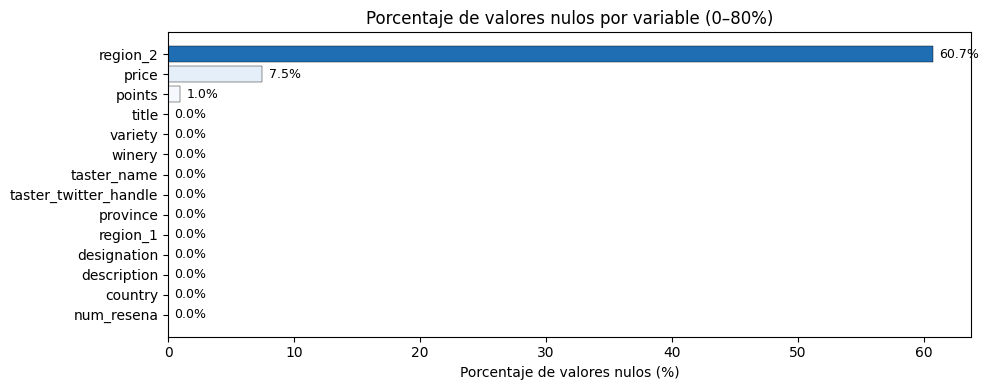

In [111]:
# Calcular porcentaje de nulos por columna
null_percent = (df.isna().sum() / len(df)) * 100
missing_df = pd.DataFrame({
    'null_count': df.isna().sum(),
    'null_percent': null_percent
}).sort_values('null_percent', ascending=True)

# Selección de columnas a graficar (None = todas).
top_n = None
plot_df = missing_df.tail(top_n) if top_n else missing_df

# Colormap en escala de azules y normalización 0-80
cmap = plt.cm.Blues
norm = mpl.colors.Normalize(vmin=0, vmax=80)
colors = cmap(norm(plot_df['null_percent'].values))

# Figura
plt.figure(figsize=(10, max(4, 0.25 * len(plot_df))))
bars = plt.barh(plot_df.index, plot_df['null_percent'], color=colors, edgecolor='k', linewidth=0.3)
plt.xlabel('Porcentaje de valores nulos (%)')
plt.title('Porcentaje de valores nulos por variable (0–80%)')
plt.xlim

# Anotar porcentaje en cada barra
for i, (val, name) in enumerate(zip(plot_df['null_percent'], plot_df.index)):
    plt.text(val + 0.5, i, f"{val:.1f}%", va='center', fontsize=9)

plt.tight_layout()
plt.show()

In [112]:
#Filtro de precios no validos (negativos) 
df_price_valid= df[df['price'] >= 0 ]

#Calculo de IQR para detectar outliers en price
Q1 = df_price_valid['price'].quantile(0.25)
Q3 = df_price_valid['price'].quantile(0.75)
IQR = Q3 - Q1                          

# Limites del metodo IQR
lim_inf_price = Q1 - 1.5 * IQR
lim_sup_price = Q3 + 1.5 * IQR

outliers_price = df_price_valid[ (df_price_valid['price'] > lim_sup_price)] #Deteccion de outliers superiores. Solo se consideran outliers por encima del limite superior

len(outliers_price)
print('Q1:', Q1)
print('Q3:', Q3)
print('IQR:', IQR)
print(f"Límite inferior: {lim_inf_price:}")
print(f"Límite superior: {lim_sup_price:}")
print('Cantidad de outliers:', len(outliers_price))


Q1: 17.0
Q3: 42.0
IQR: 25.0
Límite inferior: -20.5
Límite superior: 79.5
Cantidad de outliers: 7641


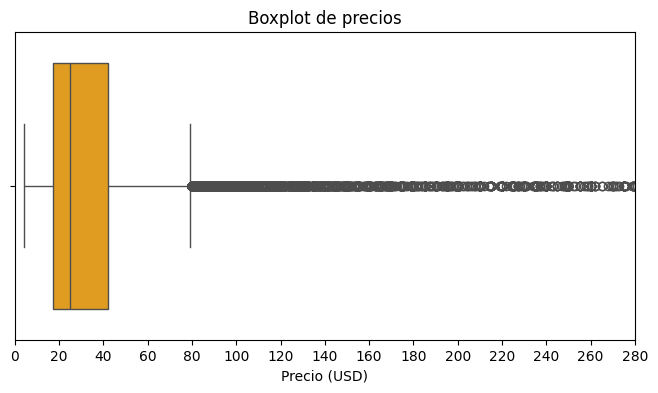

In [113]:
#boxplot variable price

plt.figure(figsize=(8,4))
sns.boxplot(x=df['price'], color='orange') 
plt.title('Boxplot de precios')
plt.xlabel('Precio (USD)')
plt.xlim(0, 200)                # Se acota el eje X para evitar que los outliers extremos aplasten la visualización
plt.xticks(range(0, 300 , 20)) #Rango acotado hasta 300usd

plt.show()

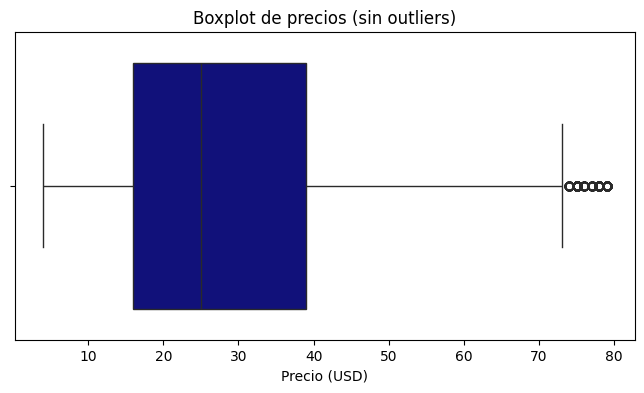

In [114]:
# Boxplot variable price sin outliers
plt.figure(figsize=(8,4))
# Se grafica unicamente el subconjunto de precios dentro del limite superior del IQR
sns.boxplot(x=df_price_valid[df_price_valid['price'] <= lim_sup_price]['price'], color= 'darkblue')
plt.title('Boxplot de precios (sin outliers)')
plt.xlabel('Precio (USD)')
plt.show()

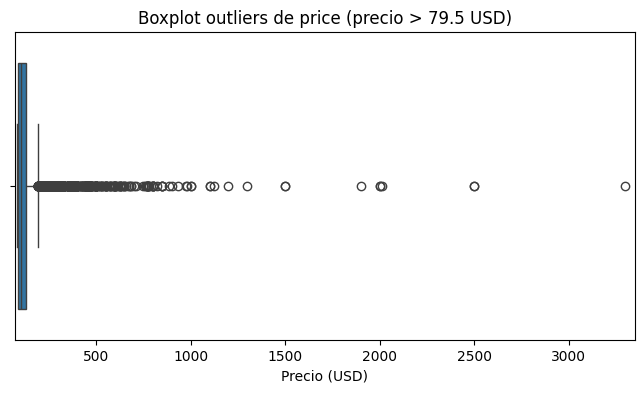

In [242]:
#Boxplot de outliers de la variable price
plt.figure(figsize=(8,4))
# Se grafica unicamente el subconjunto de precios considerados outliers (precio > 79.5 USD)
sns.boxplot(x=outliers_price['price'])
plt.title('Boxplot outliers de price (precio > 79.5 USD)')
plt.xlabel('Precio (USD)')
plt.xlim(70, 3350) # Se acota el eje X para visualizar correctamente los valores extremos
plt.show()

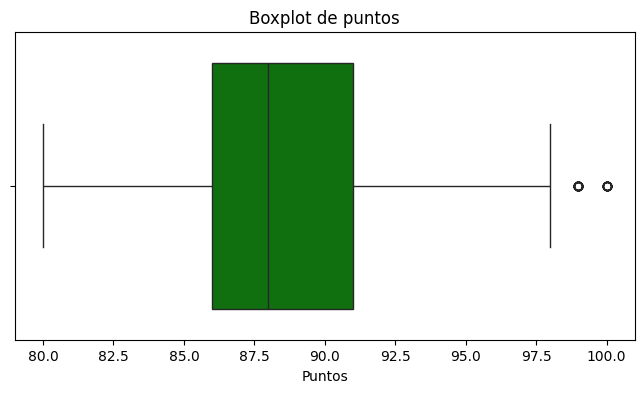

In [243]:
#Boxplot de la variable points
plt.figure(figsize=(8,4))
sns.boxplot(x=df['points'], color='green')
plt.title('Boxplot de puntos')
plt.xlabel('Puntos')
plt.show()

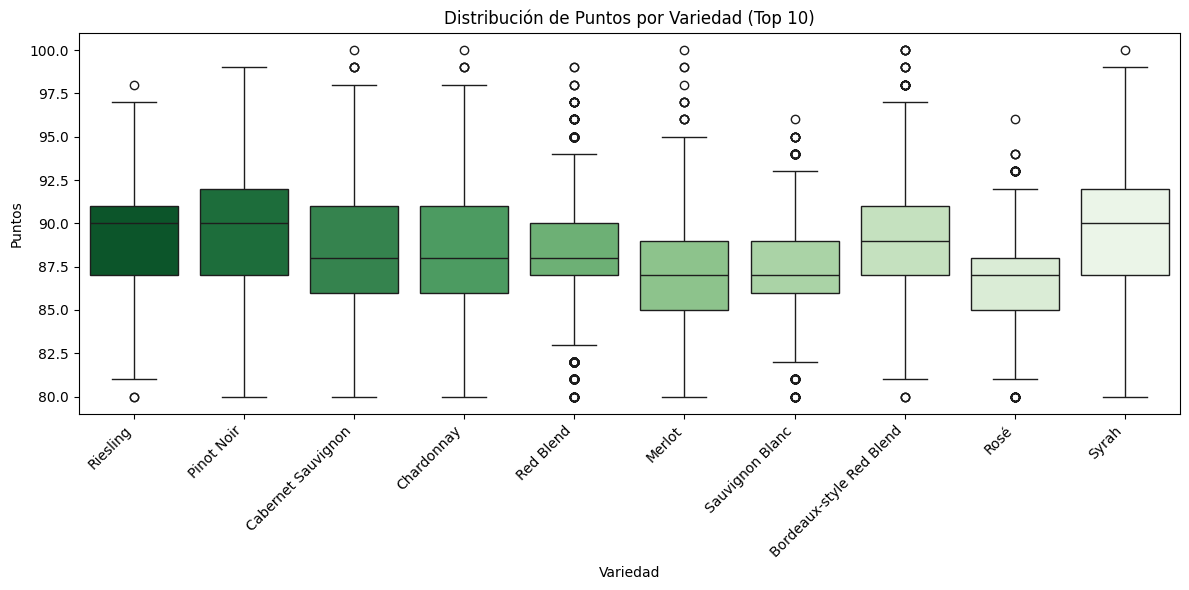

In [246]:
#Obtiene el TOP 10 de variedades 
top_varieties = df['variety'].value_counts().head(10).index

#Filtrar el dataframe solo a esas variedades
df_top10 = df[df['variety'].isin(top_varieties)]

# Crear el boxplot
plt.figure(figsize=(12,6))
sns.boxplot(
    data=df_top10,
    x='variety',
    y='points',
    hue='variety',
    palette='Greens_r',
    legend=False 
)

plt.xticks(rotation=45, ha='right')
plt.title('Distribución de Puntos por Variedad (Top 10)')
plt.xlabel('Variedad')
plt.ylabel('Puntos')
plt.tight_layout()
plt.show()


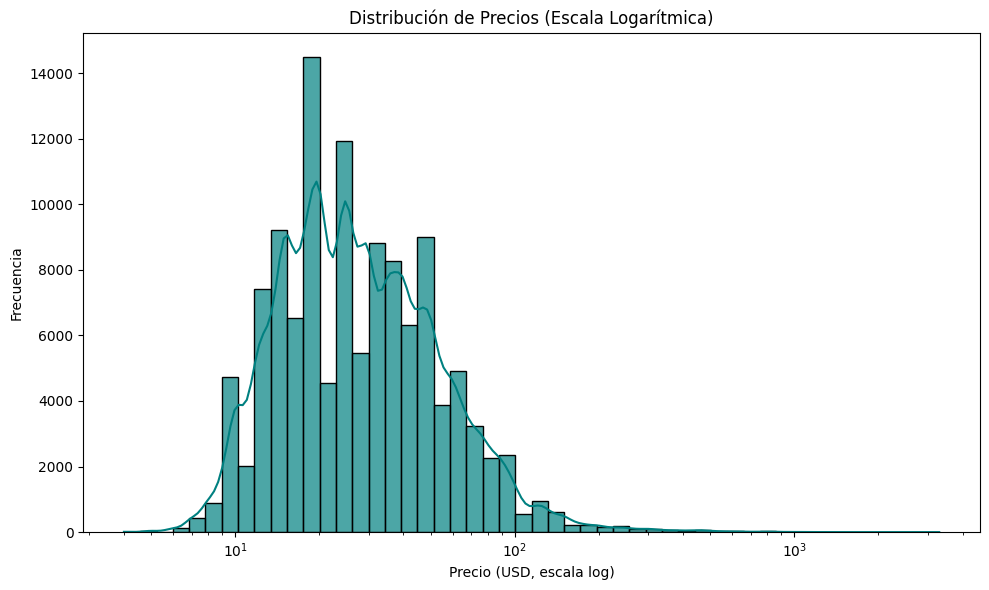

In [129]:
#Distribucion de Precios (Escala Logaritmica)
plt.figure(figsize=(10,6))

sns.histplot(
    data=df,
    x='price',
    bins=50,
    kde=True,
    log_scale=True,     # escala logarítmica al eje x
    color='teal',
    alpha=0.7
)

plt.title('Distribucion de Precios (Escala Logaritmica)')
plt.xlabel('Precio (USD, escala log)')
plt.ylabel('Frecuencia')
plt.tight_layout()
plt.show()


In [153]:
# Segmentacion de precios en 3 grupos (terciles) 
df['price_segment'] = pd.qcut(
    df['price'],
    q=3,      # divide en 3 partes iguales segun distribucion real
    labels=['Economico', 'Medio', 'Premium']
)
# Conteo por segmento
segment_counts = df['price_segment'].value_counts().sort_index()
# Porcentaje por segmento
segment_percent = df['price_segment'].value_counts(normalize=True).sort_index() * 100

print(segment_counts)
print(segment_percent)

price_segment
Economico    45884
Medio        34524
Premium      39823
Name: count, dtype: int64
price_segment
Economico   38.16
Medio       28.71
Premium     33.12
Name: proportion, dtype: float64


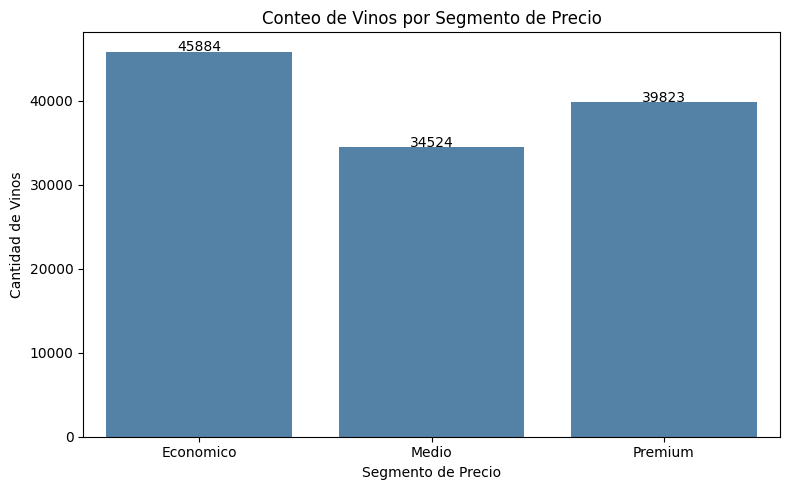

In [165]:
#grafico cantidad de vinos por segmento de precio
plt.figure(figsize=(8,5))
sns.barplot(
    x=segment_counts.index,
    y=segment_counts.values,
    color='steelblue'  
)

plt.title('Conteo de Vinos por Segmento de Precio')
plt.xlabel('Segmento de Precio')
plt.ylabel('Cantidad de Vinos')

# Etiquetas encima de cada barra
for i, value in enumerate(segment_counts.values):
    plt.text(i, value + 50, str(value), ha='center')

plt.tight_layout()
plt.show()


In [155]:
#Tabla combinada: conteo + porcentaje
segment_table = pd.DataFrame({
    'Conteo': segment_counts,     # cantidad de vinos por segmento
    'Porcentaje (%)': segment_percent.round(2) # porcentaje redondeado a 2 decimales
})

segment_table


,Conteo,Porcentaje (%)
price_segment,,
Economico,45884,38.16
Medio,34524,28.71
Premium,39823,33.12


In [247]:
#metrica Quality–Price Ratio
df['qpr'] = df['points'] / df['price']     # QPR = points / price  mide cuántos puntos obtiene un vino segun su precio
# Filtrar valores validos
df_qpr = df[(df['price'] > 0) & (df['qpr'].notna())]            # Filtrar valores validos: precio > 0 y QPR no nulo
#Top 10 vinos con mejor QPR
top10_qpr = df_qpr.nlargest(10, 'qpr')
top10_qpr

,num_resena,country,description,designation,points,price,province,region_1,region_2,taster_name,taster_twitter_handle,title,variety,winery,price_segment,qpr
64590,64590,US,"There's a lot going on in this Merlot, which i...",Unknown,86.00,4.00,California,California,California Other,Unknown,Unknown,Bandit NV Merlot (California),Merlot,Bandit,Economico,21.50
126096,126096,Romania,Notes of sun-dried hay and green flower highli...,UnWineD,86.00,4.00,Viile Timisului,Unknown,NaN,Anna Lee C. Iijima,Unknown,Cramele Recas 2011 UnWineD Pinot Grigio (Viile...,Pinot Grigio,Cramele Recas,Economico,21.50
1987,1987,Spain,Berry and cherry aromas are surprisingly sturd...,Flirty Bird,85.00,4.00,Central Spain,Vino de la Tierra de Castilla,NaN,Michael Schachner,@wineschach,Felix Solis 2013 Flirty Bird Syrah (Vino de la...,Syrah,Felix Solis,Economico,21.25
20484,20484,US,"Fruity, soft and rather sweet, this wine smell...",Unknown,85.00,4.00,California,Clarksburg,Central Valley,Jim Gordon,@gordone_cellars,Dancing Coyote 2015 White (Clarksburg),White Blend,Dancing Coyote,Economico,21.25
29553,29553,Argentina,"Crimson in color but also translucent, with a ...",Red,84.00,4.00,Mendoza Province,Mendoza,NaN,Michael Schachner,@wineschach,Broke Ass 2009 Red Malbec-Syrah (Mendoza),Malbec-Syrah,Broke Ass,Economico,21.00
31530,31530,US,"Packaged in a cute yellow recyclable Tetrapak,...",Unknown,84.00,4.00,California,California,California Other,Unknown,Unknown,Bandit NV Chardonnay (California),Chardonnay,Bandit,Economico,21.00
61768,61768,Spain,This opens with standard cherry and berry arom...,Unknown,84.00,4.00,Levante,Yecla,NaN,Michael Schachner,@wineschach,Terrenal 2010 Cabernet Sauvignon (Yecla),Cabernet Sauvignon,Terrenal,Economico,21.00
110255,110255,US,"A good everyday Merlot, dry and rich in tannin...",Unknown,84.00,4.00,California,California,California Other,Unknown,Unknown,Bandit NV Merlot (California),Merlot,Bandit,Economico,21.00
112919,112919,Spain,"Nice on the nose, this has a leafy note and a ...",Estate Bottled,84.00,4.00,Levante,Yecla,NaN,Michael Schachner,@wineschach,Terrenal 2010 Estate Bottled Tempranillo (Yecla),Tempranillo,Terrenal,Economico,21.00
59507,59507,US,"Sweet and fruity, this canned wine feels soft ...",Unoaked,83.00,4.00,California,California,California Other,Jim Gordon,@gordone_cellars,Pam's Cuties NV Unoaked Chardonnay (California),Chardonnay,Pam's Cuties,Economico,20.75


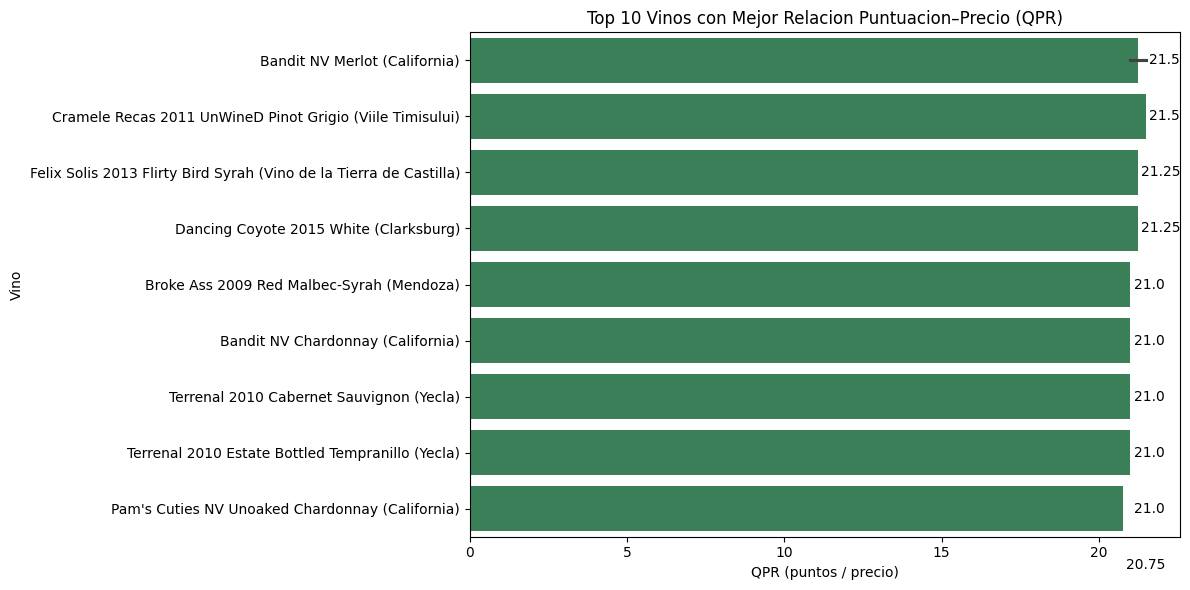

In [175]:
#Grafico Quality–Price (Top 10)
plt.figure(figsize=(12,6))

sns.barplot(
    data=top10_qpr,
    x='qpr',
    y='title',      
    color='seagreen'
)

plt.title('Top 10 Vinos con Mejor Relacion Puntuacion–Precio (QPR)')
plt.xlabel('QPR (puntos / precio)')
plt.ylabel('Vino')

# Etiquetas al final de cada barra
for i, value in enumerate(top10_qpr['qpr']):
    plt.text(value + 0.1, i, round(value, 2), va='center')

plt.tight_layout()
plt.show()


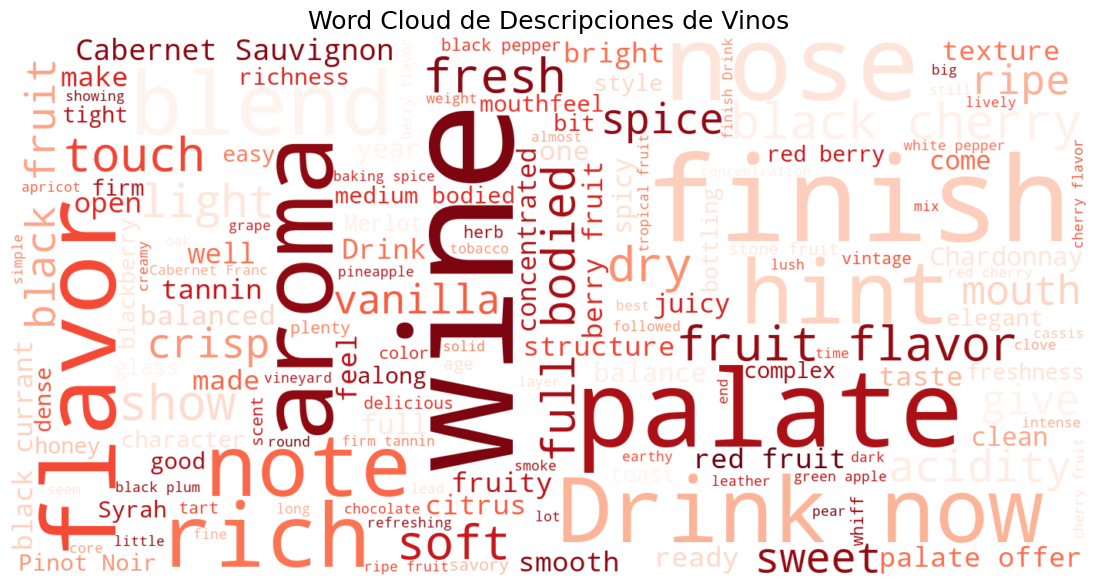

In [197]:
#word cloud
# Se unen todos los textos de la columna description en un solo string
text = " ".join(df['description'].dropna().astype(str))

# Se crea la nube de palabras 
wordcloud = WordCloud(
    width=1400,
    height=700,
    background_color='white',
    colormap='Reds',         
    max_words=150,
    prefer_horizontal=0.9,   
     contour_color='firebrick',   
    contour_width=1,
    min_font_size=10,
    max_font_size=200
).generate(text)

#Se muestra la nube
plt.figure(figsize=(14,7))
plt.imshow(wordcloud, interpolation='bilinear')
plt.axis('off')
plt.title('Word Cloud de Descripciones de Vinos', fontsize=18)
plt.show()


In [213]:
#Preprocesamiento de texto para el analisis de frecuencia
# Se unen todas las descripciones en un solo string y se pasan a minúsculas
text = " ".join(df['description'].dropna().astype(str)).lower()

# Se quitan signos y se dejan solo palabras
text = re.sub(r'[^a-zA-Záéíóúñü\s]', '', text)

# Se separan las palabras
words = text.split()

# Lista de stopwords basicas
stopwords = [
    'the','and','of','to','a','in','with','is','this','that','for','on','it',
    'its','wine','flavors','aromas','notes','palate','finish','nose','fruit', 'from', 'but',
    'are','has','by','as','an','now', 'drink', 'offers'
]

# Se filtran stopwords
filtered_words = [w for w in words if w not in stopwords]

# Se cuenta la frecuencia de palabras
word_counts = Counter(filtered_words).most_common(20)


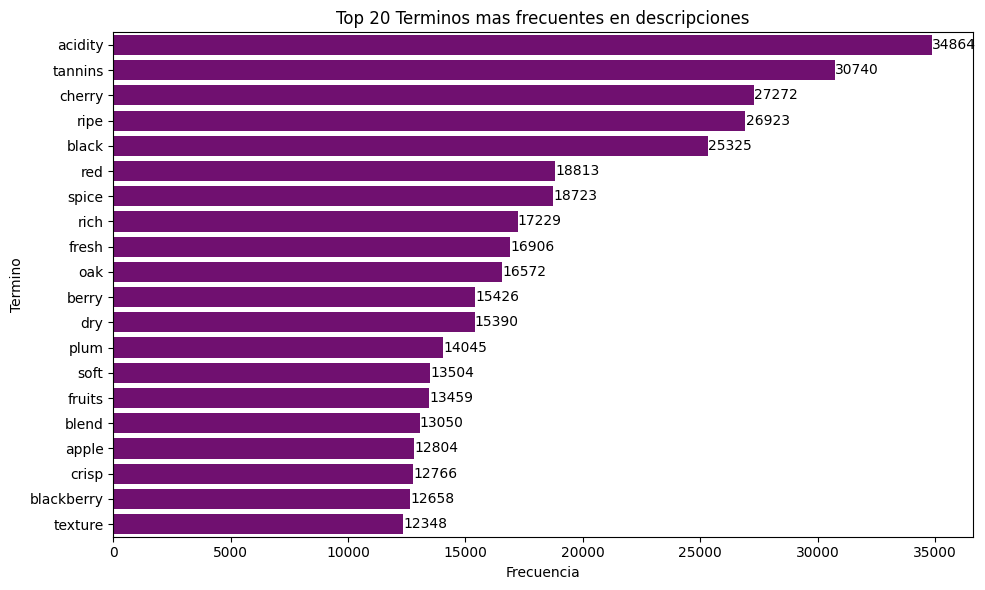

In [214]:
# Top 20 terminos mas frecuentes en descripciones
import seaborn as sns
plt.figure(figsize=(10,6))

sns.barplot(
    x=[count for word, count in word_counts],
    y=[word for word, count in word_counts],
    color='purple'
)

plt.title('Top 20 Terminos mas frecuentes en descripciones')
plt.xlabel('Frecuencia')
plt.ylabel('Termino')

# Etiquetas al final de cada barra
for i, (word, count) in enumerate(word_counts):
    plt.text(count + 3, i, str(count), va='center')  

plt.tight_layout()
plt.show()

In [217]:
#Se separan los textos por rango de puntos
high = df[df['points'] >= 90]['description'].dropna().astype(str)
low  = df[df['points'] < 85]['description'].dropna().astype(str)

#Funcion para limpiar texto y contar palabras
import re
from collections import Counter

#Lista de stopwords
stopwords = [
    'the','and','of','to','a','in','with','is','this','that','for','on','it',
    'its','wine','flavors','aromas','notes','palate','finish','nose','fruit', 'but',
    'from','by','as','are','an','be','has','have', 'not', 'some', 'like', 'while', 'now'
]

def get_word_counts(series):
    text = " ".join(series).lower()
    text = re.sub(r'[^a-zA-Záéíóúñü\s]', '', text)
    words = text.split()
    words = [w for w in words if w not in stopwords and len(w) > 2]
    return Counter(words).most_common(15)

#Se obtienen las 15 palabras mas frecuentes por grupo
high_counts = get_word_counts(high)
low_counts  = get_word_counts(low)

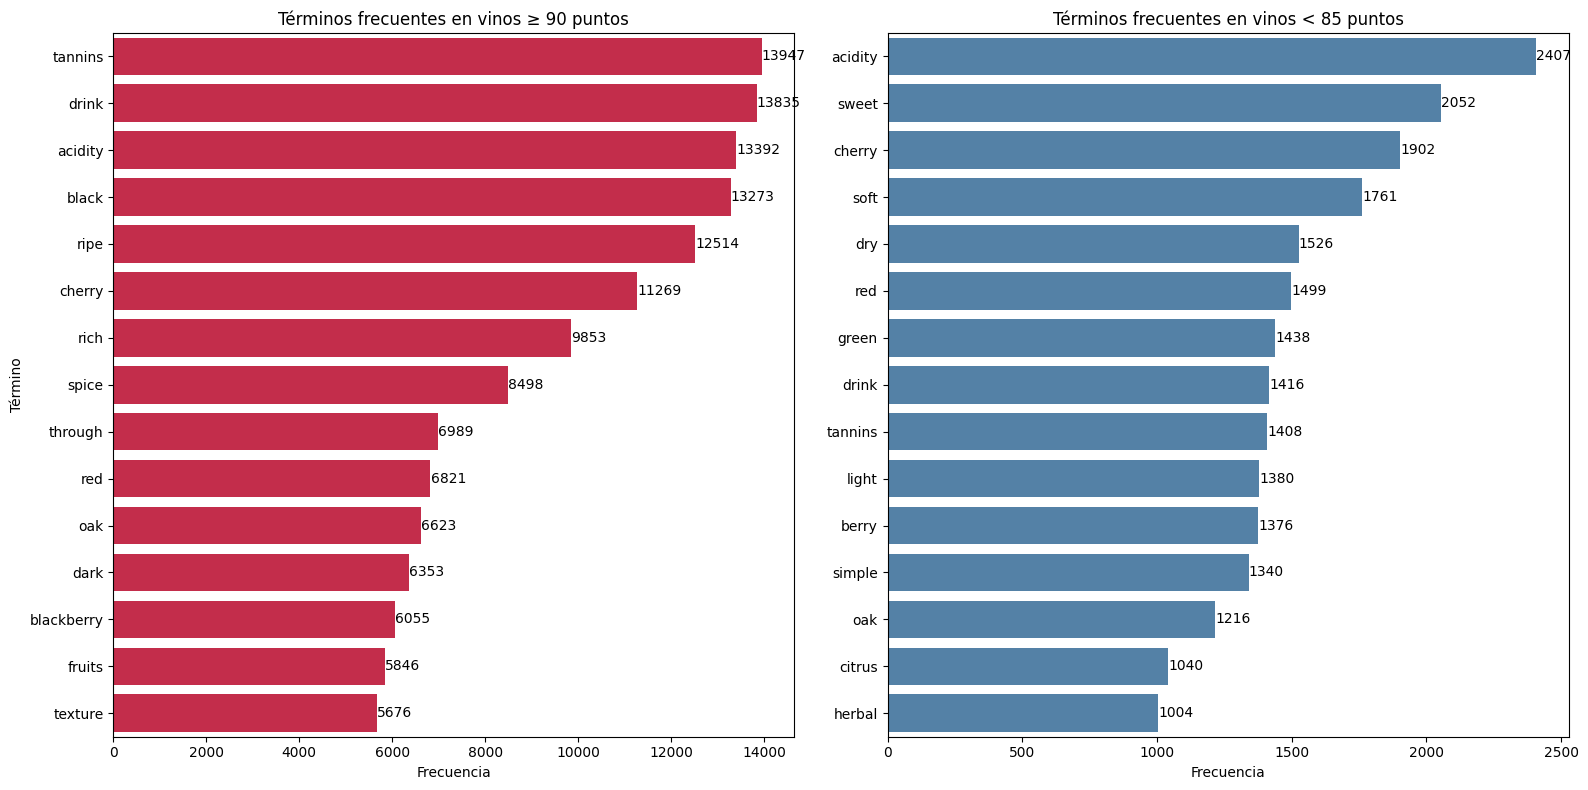

In [218]:
#grafico comparativo de terminos frecuentes segun su puntaje
fig, axes = plt.subplots(1, 2, figsize=(16,8))

# Alta calidad reseñas con puntajes (>=90) 
sns.barplot(
    x=[count for word, count in high_counts],
    y=[word for word, count in high_counts],
    color='crimson',
    ax=axes[0]
)
axes[0].set_title('Terminos frecuentes en vinos ≥ 90 puntos')
axes[0].set_xlabel('Frecuencia')
axes[0].set_ylabel('Termino')

for i, (word, count) in enumerate(high_counts):
    axes[0].text(count + 0.5, i, str(count), va='center')

#Baja calidad reseñas con puntaje(<85) 
sns.barplot(
    x=[count for word, count in low_counts],
    y=[word for word, count in low_counts],
    color='steelblue',
    ax=axes[1]
)
axes[1].set_title('Terminos frecuentes en vinos < 85 puntos')
axes[1].set_xlabel('Frecuencia')
axes[1].set_ylabel('')

for i, (word, count) in enumerate(low_counts):
    axes[1].text(count + 0.5, i, str(count), va='center')

plt.tight_layout()
plt.show()

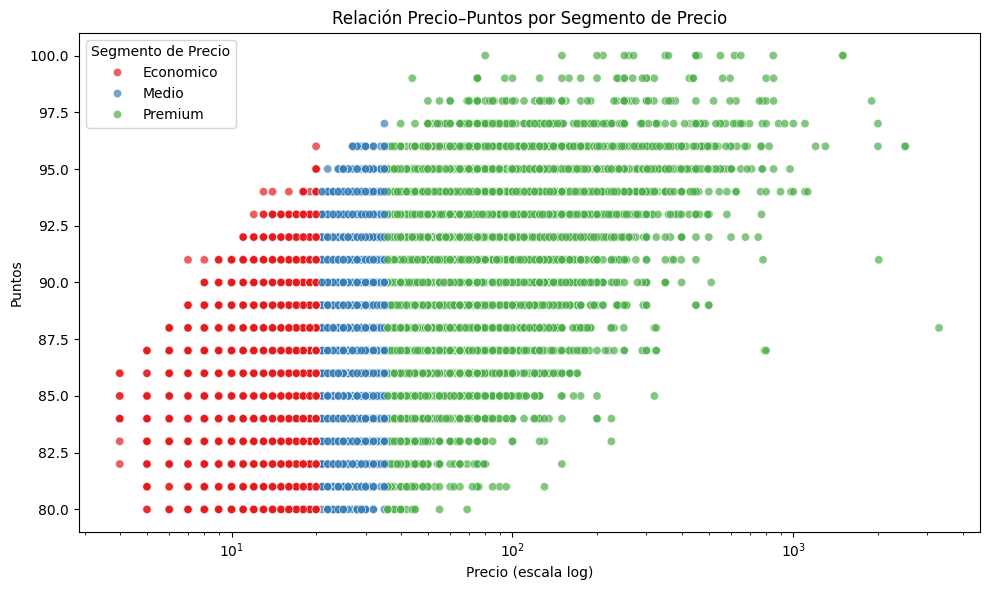

In [233]:
#Grafico de dispersion coloreado por segmento de precio
plt.figure(figsize=(10,6))

sns.scatterplot(
    data=df,
    x='price',
    y='points',
    hue='price_segment',
    palette='Set1',
    alpha=0.7
)

plt.xscale('log')  # Escala logaritmica para el precio para mejorar la visualizacion
plt.xlabel('Precio (escala log)')
plt.ylabel('Puntos')
plt.title('Relación Precio–Puntos por Segmento de Precio')
plt.legend(title='Segmento de Precio')
plt.tight_layout()
plt.show()


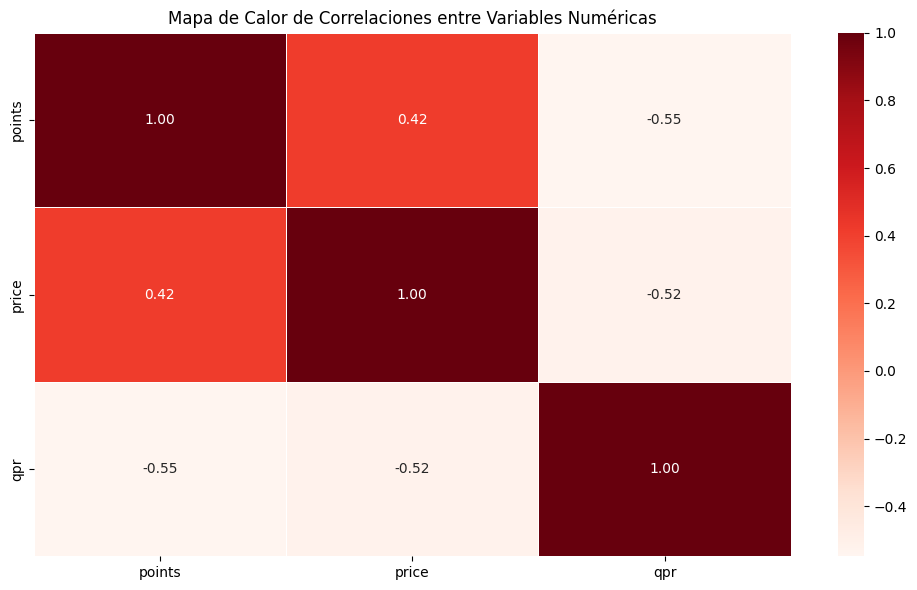

In [248]:
#Heatmap de correlaciones entre variables numericas 
plt.figure(figsize=(10,6))

# Se calcula la matriz de correlacion solo con variables numericas
corr = df.select_dtypes(include=['float64', 'int64']).corr()

# Se crea el mapa de calor
sns.heatmap(
    corr,
    annot=True,          # Muestra los valores numericos dentro de cada celda
    cmap='Reds',        
    linewidths=0.5,      # Lineas divisorias entre celdas
    fmt='.2f'           
)

plt.title('Mapa de Calor de Correlaciones entre Variables Numéricas')
plt.tight_layout()
plt.show()


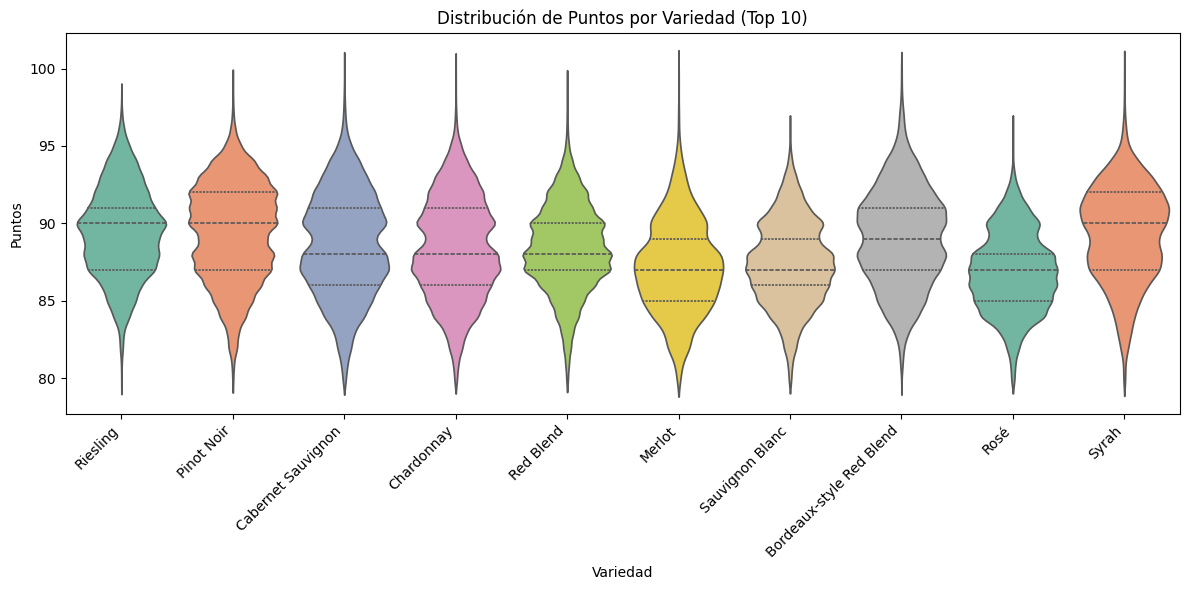

In [251]:
# Violin plot de puntos por variedad (Top 10 variedades con mas vinos)

# Se obtienen las 10 variedades con mayor cantidad de vinos en el dataset
top10_varieties = df['variety'].value_counts().head(10).index

#Se filtra el dataframe solo a esas variedades
df_top10 = df[df['variety'].isin(top10_varieties)]

plt.figure(figsize=(12,6))

#Se Crea el violin plot
sns.violinplot(
    data=df_top10,
    x='variety',         
    y='points',  
    hue= 'variety',
    palette='Set2',  
    inner='quartile',       # Muestra mediana y cuartiles dentro del violin
    legend= False 
)

plt.xticks(rotation=45, ha='right')
plt.xlabel('Variedad')
plt.ylabel('Puntos')
plt.title('Distribución de Puntos por Variedad (Top 10)')
plt.tight_layout()

plt.show()